# 3. Relative risk without absolute risk

**The mistake in one sentence:** a big percentage of a small number is still a small number.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/USERNAME/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

In October 2015 the World Health Organization said that 50 grams of processed meat a day raises bowel cancer risk by 18 percent. Front pages said bacon causes cancer.

Cancer Research UK put the same finding in real numbers. Out of 1,000 people who eat little processed meat, about 56 get bowel cancer in their lifetime. Out of 1,000 who eat the most, about 66.

In [3]:
cruk = pd.read_csv(dms.DATA / "bowel_cancer_cruk_2015.csv", index_col="group").cases_per_1000
cruk

group
low processed meat     56
high processed meat    66
Name: cases_per_1000, dtype: int64

In [4]:
def describe_risk(cases_before, cases_after, per):
    return pd.Series({
        "risk before": f"{cases_before} in {per:,}",
        "risk after": f"{cases_after} in {per:,}",
        "relative risk": round(cases_after / cases_before, 2),
        "headline increase (%)": round((cases_after / cases_before - 1) * 100),
        "absolute increase (per 1000)": round((cases_after - cases_before) / per * 1000, 2),
        "number needed to harm": round(per / (cases_after - cases_before)),
    })

pd.DataFrame({
    "bacon, 2015": describe_risk(cruk["low processed meat"], cruk["high processed meat"], 1000),
    "pill scare, 1995": describe_risk(1, 2, 7000),
})

,"bacon, 2015","pill scare, 1995"
risk before,"56 in 1,000","1 in 7,000"
risk after,"66 in 1,000","2 in 7,000"
relative risk,1.18,2.0
headline increase (%),18,100
absolute increase (per 1000),10.0,0.14
number needed to harm,100,7000


Two famous scares, side by side. Bacon: 18 percent more risk, which is 10 extra people in 1,000. About 100 people must eat processed meat every day for one extra case.

The pill: the risk doubled, from 1 in 7,000 to 2 in 7,000. Many women stopped the pill, and the next year saw thousands more abortions in the UK.

## Figure: 1,000 people

In [5]:
def waffle(ax, red, amber, cols=40):
    n = 1000
    xs, ys = np.arange(n) % cols, np.arange(n) // cols
    colors = np.array([dms.GREY] * n, dtype=object)
    colors[:red] = dms.RED
    colors[red:red + amber] = dms.AMBER
    ax.scatter(xs, -ys, s=22, c=list(colors))
    ax.set_aspect("equal"); ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
waffle(axes[0], cruk["low processed meat"], 0)
axes[0].set_title(f"Little processed meat: {cruk['low processed meat']} in 1,000")
waffle(axes[1], cruk["low processed meat"], cruk["high processed meat"] - cruk["low processed meat"])
axes[1].set_title(f"Every day: {cruk['high processed meat']} in 1,000. That is the 18 percent.")
dms.save(fig, "03_relative_vs_absolute.png")
plt.show()

## Animated figure

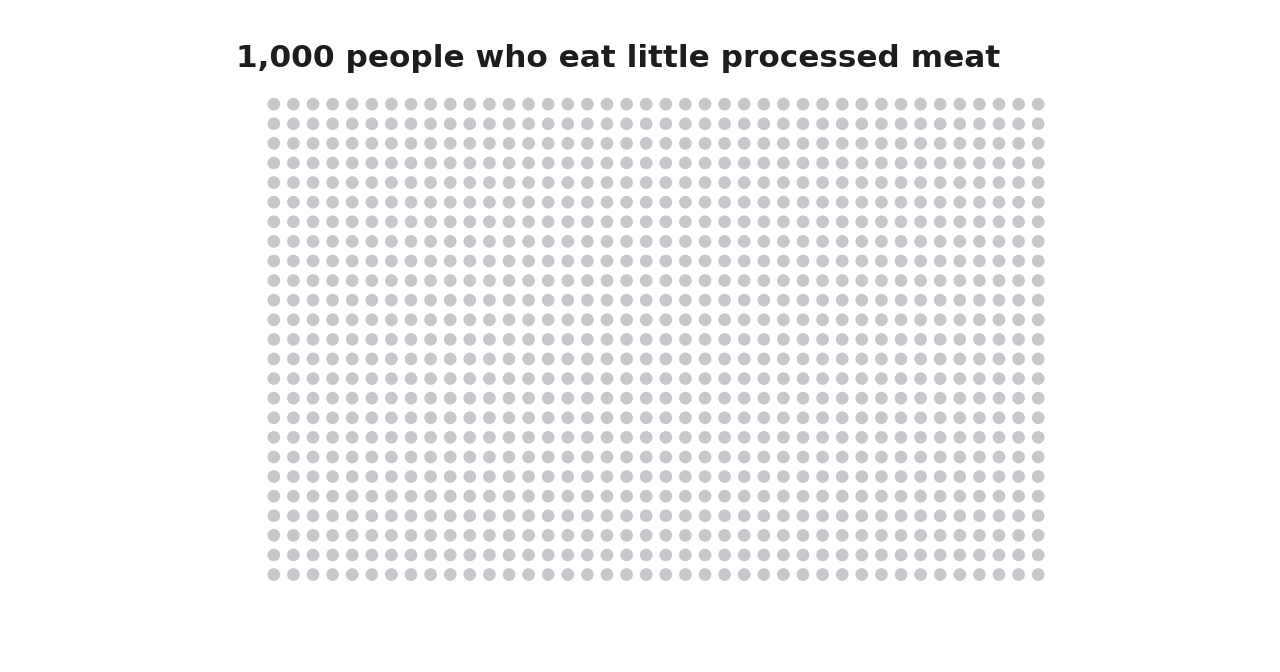

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
n, cols = 1000, 40
xs, ys = np.arange(n) % cols, -(np.arange(n) // cols)
dots = ax.scatter(xs, ys, s=22, c=[dms.GREY] * n)
ax.set_aspect("equal"); ax.axis("off")
title = ax.set_title("1,000 people")
low, high = int(cruk["low processed meat"]), int(cruk["high processed meat"])

def update(i):
    colors = np.array([dms.GREY] * n, dtype=object)
    if i >= 8:
        colors[:min(low, (i - 8) * 4)] = dms.RED
    if i >= 30:
        colors[:low] = dms.RED
        colors[low:low + min(high - low, i - 30)] = dms.AMBER
    dots.set_color(list(colors))
    if i < 8:
        title.set_text("1,000 people who eat little processed meat")
    elif i < 24:
        title.set_text("Some get bowel cancer anyway")
    elif i < 30:
        title.set_text(f"{low} in 1,000 over a lifetime")
    elif i < 44:
        title.set_text("Headline: processed meat raises the risk by 18%")
    else:
        title.set_text(f"18% means {high - low} more people. {high} in 1,000.")
    return dots, title

anim = FuncAnimation(fig, update, frames=58, interval=150)
gif = dms.FIG / "03_ten_more_people.gif"
anim.save(gif, writer=PillowWriter(fps=6))
plt.close(fig)
display(Image(filename=str(gif)))

## Better method

Always show the absolute numbers next to the percent: 56 in 1,000 becomes 66 in 1,000. Add the number needed to harm: how many people must do the thing for one extra case. Here it is about 100.

## Ask this

18 percent of what?